In [2]:
import numpy as np
import matplotlib.pyplot as plt

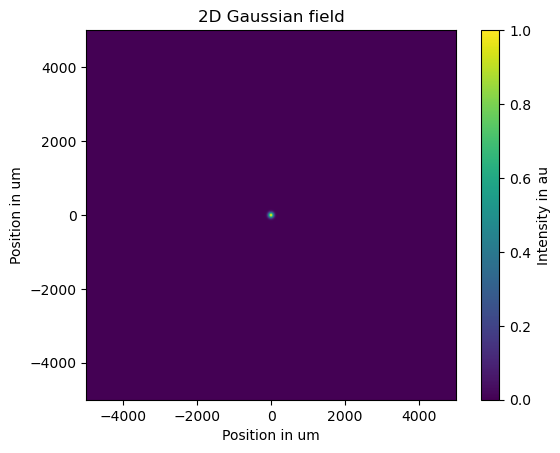

In [13]:
dx_m = 1e-6 #grid size, m:meter
Dx_m = 10e-3 #screen size
x_m = np.linspace(-Dx_m/2, Dx_m/2, int(Dx_m/dx_m)+1) #spatial grid along x-axis 

x_mean_m = 0.0 #centered on...
x_std_m = 50e-6 #widthofgaussian



dy_m = 1e-6 #grid size, m:meter
Dy_m = Dx_m
y_m = np.linspace(-Dy_m/2, Dy_m/2, int(Dy_m/dy_m)+1) #spatial grid along y-axis 



X, Y = np.meshgrid(x_m, y_m) #2D grid
uin_V_m = np.exp(-(X**2 + Y**2)/(2*(x_std_m**2))) #2D Gaussian field
plt.imshow(uin_V_m, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("2D Gaussian field")
plt.colorbar(label="Intensity in au")
plt.show()

In [ ]:
# def propTF2(uin_V_m, Lx_m, Ly_m, lambda_m, z_m):
#     """
#     2D transfer-function Fresnel propagation.
#     uin_V_m: 2D input field (Ny, Nx)
#     Lx_m, Ly_m: physical sizes of the window in x and y (meters)
#     lambda_m: wavelength (meters)
#     z_m: propagation distance (meters)
#     """
#     Ny, Nx = uin_V_m.shape
#     dx = Lx_m / Nx
#     dy = Ly_m / Ny

#     # frequency coordinates (cycles per meter), centered
#     fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
#     fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))
#     FX, FY = np.meshgrid(fx, fy)

#     # 2D transfer function for Fresnel propagation
#     H = np.exp(-1j * np.pi * lambda_m * z_m * (FX**2 + FY**2))

#     # Forward 2D FFT (shift input to center first)
#     Uin = np.fft.fft2(np.fft.fftshift(uin_V_m))

#     # Multiply in frequency domain and inverse FFT (then unshift)
#     Uout = H * Uin
#     uout = np.fft.ifftshift(np.fft.ifft2(Uout))

#     return uout

In [11]:
def ft(t):
    return np.fft.fftshift( np.fft.fft2(np.fft.ifftshift(t)))

def ift(t):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(t)))

def fs(t):
    # works with Matlab, breaks with python
    #return (np.arange(0,1/(t[1]-t[0]),1/((t[1]-t[0])*len(t)))) - (1/(t[1]-t[0])-np.mod(len(t),2)*1/((t[1]-t[0])*len(t)))/2
    
    # from https://stackoverflow.com/questions/3694918/how-to-extract-frequency-associated-with-fft-values-in-python
    N = len(t)
    df_cpm = 1/(t[-1]-t[0])
    f_cpm = np.fft.fftshift(np.array([df_cpm*n if n<N/2 else df_cpm*(n-N) for n in range(N)]))
    return f_cpm

def propTF(E_in,L_m,lambda_m,z_m):
    #get input field array size
    (Nx, Ny)=np.shape(E_in); 
    dx=L_m/Nx; #sample interval

    #(dx<lambda.*z/L)


    fx = fs(np.arange(Nx)*dx);
    if Ny>2:
        fy = fs(np.arange(Ny)*dx);
    else:
        fy = 0;

    [FX,FY]= np.meshgrid(fx,fy);

    H=np.exp(-1j*np.pi*lambda_m*z_m*(FX**2+FY**2))

    E_out = ft(ft(E_in)*H);
    
    return E_out


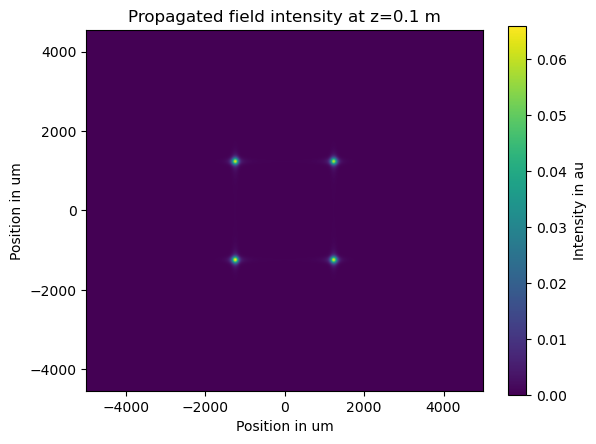

In [9]:
field = propTF2(uin_V_m, Dx_m, Dy_m, 500e-9, 0.005)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Propagated field intensity at z=0.1 m")
plt.colorbar(label="Intensity in au")
plt.show()

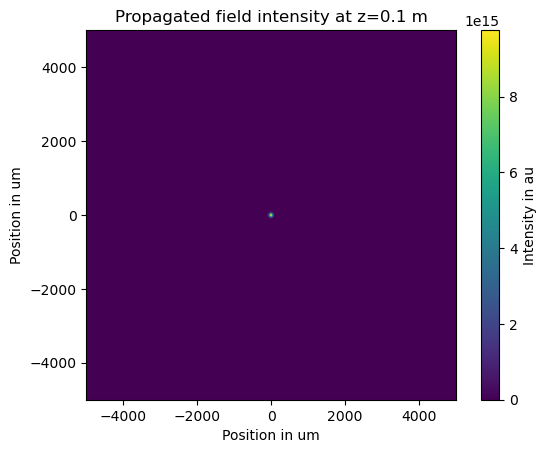

In [14]:
field = propTF(uin_V_m, Dx_m, 500e-9, 0.005)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Propagated field intensity at z=0.1 m")
plt.colorbar(label="Intensity in au")
plt.show()

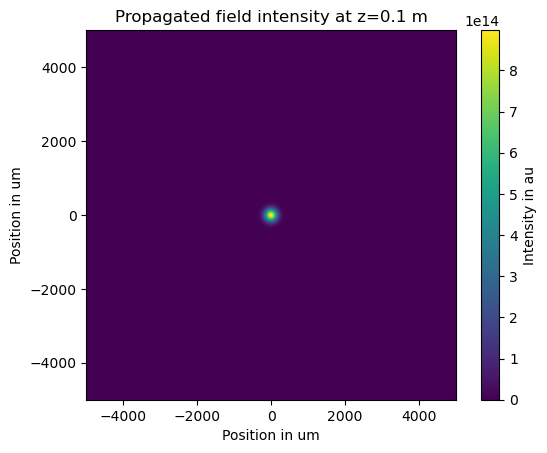

In [15]:
field = propTF(uin_V_m, Dx_m, 500e-9, 0.1)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Propagated field intensity at z=0.1 m")
plt.colorbar(label="Intensity in au")
plt.show()

In [37]:
x_mean_m = 0.0 #centered on...
x_std_m = 1e-3 #widthofgaussian



dy_m = 1e-6 #grid size, m:meter
Dy_m = Dx_m
y_m = np.linspace(-Dy_m/2, Dy_m/2, int(Dy_m/dy_m)+1) #spatial grid along y-axis 


X, Y = np.meshgrid(x_m, y_m) #2D grid
uin_V_m = np.exp(-(X**2 + Y**2)/(2*(x_std_m**2))) #2D Gaussian field


phase = np.random.rand(*X.shape)*2*np.pi/4 #random phase, like adding diffuser 
# spatial low-pass filter the phase in the frequency domain (Gaussian)
filter_sigma_m = 10e-6  # smoothing scale in meters (adjust as needed)
#filter_sigma_m: if make it smaller, will get bigger bloom in fourier transform

Ny, Nx = phase.shape
fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx_m))
fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy_m))
FX, FY = np.meshgrid(fx, fy)

sigma_f = 1.0 / filter_sigma_m 
H = np.exp(- (FX**2 + FY**2) / (2 * sigma_f**2))

Ph_ft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(phase)))
phase_filtered = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(Ph_ft * H)))
phase = np.real(phase_filtered)

especkle = uin_V_m * np.exp(1j * phase)  # speckle field with spatially filtered phase



# plt.imshow(uin_V_m, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
# plt.xlabel("Position in um")
# plt.ylabel("Position in um")
# plt.title("2D Gaussian field")
# plt.colorbar(label="Intensity in au")
# plt.show()

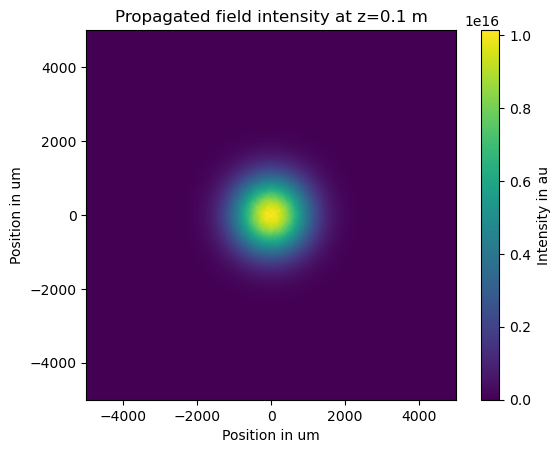

In [33]:
field = propTF(especkle, Dx_m, 500e-9, 0.1)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Propagated field intensity at z=0.1 m")
plt.colorbar(label="Intensity in au")
plt.show()

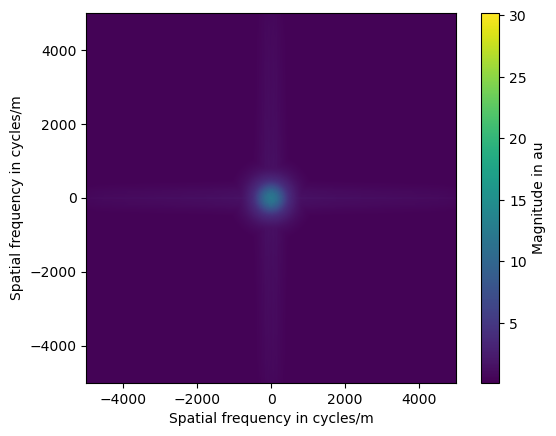

In [ ]:
ftfield = ft(field)
plt.imshow(np.abs(ftfield)**0.1, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Spatial frequency in cycles/m")
plt.ylabel("Spatial frequency in cycles/m") 
plt.colorbar(label="Magnitude in au")
plt.show()

#halo in fourier domain will expand if change filter_sigma_m, if halo is too small you cannot see rings

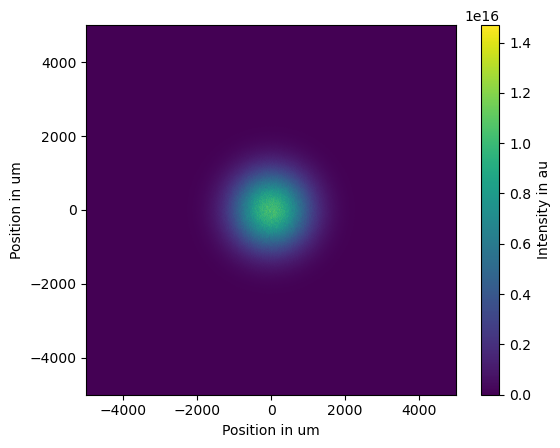

In [42]:
field = propTF(especkle, Dx_m, 500e-9, 0.001)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")       
plt.colorbar(label="Intensity in au")
plt.show()

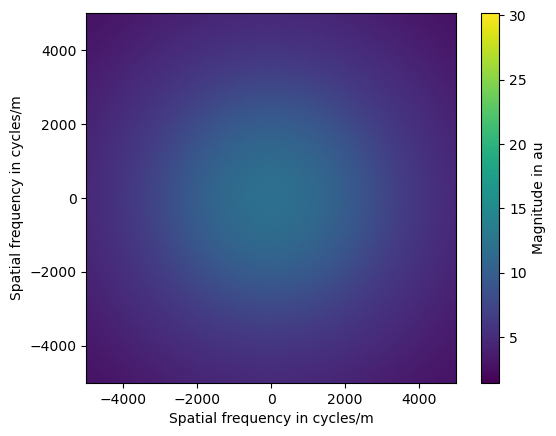

In [43]:
ftfield = ft(field)
plt.imshow(np.abs(ftfield)**0.1, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Spatial frequency in cycles/m")
plt.ylabel("Spatial frequency in cycles/m") 
plt.colorbar(label="Magnitude in au")
plt.show()

In [ ]:
#try to generate spiral phase — a phase that azimuthally changes, like a vortex beam 
#if you propagate field with flat phase, it becomes parabolic 
#can also create phase that changes dep on angle you look at it (this is vortex beam, need arctan etc)